# Attention-Enhanced Prototypical Networks for Few-Shot Learning

Imports all necessary libraries and sets up the environment

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import os
import json
import time
from tqdm import tqdm
from tqdm.auto import tqdm
import pickle
import warnings


warnings.filterwarnings('ignore')

# # Set random seeds for reproducibility
def set_seed(seed=42):
     """Set all random seeds to ensure reproducible results"""
     random.seed(seed)
     np.random.seed(seed)
     torch.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     torch.backends.cudnn.deterministic = True

set_seed(42)

# Check device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


Define all hyperparameters and configuration settings for the experiment

Classes are split into: Train (64 classes), Validation (16 classes), Test (20 classes)

No class appears in more than one split!

In [ ]:
class Config:
    """Configuration parameters for the few-shot learning experiment"""

    # Dataset Configuration
    dataset_name = 'CIFAR100'          # Dataset name
    num_classes_total = 100             # Total number of classes in CIFAR-100
    data_root = './data'                # Root directory for datasets

    # Class Split (NO OVERLAP!)
    # Standard CIFAR-100 split used in few-shot learning papers
    train_classes = list(range(64))     # Classes 0-63 for meta-training (64 classes)
    val_classes = list(range(64, 80))   # Classes 64-79 for validation (16 classes)
    test_classes = list(range(80, 100)) # Classes 80-99 for testing (20 classes)

    # Few-Shot Learning Settings
    n_way = 5                          # Number of classes per episode (5-way classification)
    k_shot = 5                         # Number of support examples per class (5-shot)
    k_query = 15                       # Number of query examples per class
    images_per_class_train = 15        # Only 15 images per class for training

    # Model Architecture
    embedding_dim = 128                # Dimension of feature embeddings
    hidden_dim = 256                   # Hidden dimension for attention network

    # Training Settings
    num_episodes = 500                 # Total number of training episodes
    num_val_episodes = 200             # Number of validation episodes
    num_test_episodes = 500            # Number of test episodes
    learning_rate = 0.001              # Learning rate for optimizer
    print_every = 500                  # Print progress every N episodes

    # Mixed-Quality Training (Blurry Images)
    use_blurry_training = True         # Whether to use blurry images during training
    blur_probability = 0.2             # 20% of support images will be blurry
    blur_strength = 'heavy'            # Blur strength: 'light', 'medium', 'heavy'

    # Paths for saving results
    save_dir = './saved_models'        # Directory to save models
    results_dir = './results'          # Directory to save results
    seed = 42                          # Random seed

    def __init__(self):
        # Create directories if they don't exist
        os.makedirs(self.save_dir, exist_ok=True)
        os.makedirs(self.results_dir, exist_ok=True)

# Create configuration instance
config = Config()

# Print configuration
print("="*70)
print("CONFIGURATION SETTINGS (WITH CLASS SEPARATION)")
print("="*70)
print(f"Few-Shot Settings: {config.n_way}-way, {config.k_shot}-shot")
print(f"Training: {config.num_episodes} episodes")
print(f"Validation: {config.num_val_episodes} episodes")
print(f"Testing: {config.num_test_episodes} episodes")
print(f"Images per class: {config.images_per_class_train} for training")
print(f"\n📊 CLASS SPLIT (NO OVERLAP!):")
print(f"  • Train classes: {len(config.train_classes)} classes (IDs: {config.train_classes[:5]}...{config.train_classes[-5:]})")
print(f"  • Validation classes: {len(config.val_classes)} classes (IDs: {config.val_classes[:5]}...{config.val_classes[-5:]})")
print(f"  • Test classes: {len(config.test_classes)} classes (IDs: {config.test_classes[:5]}...{config.test_classes[-5:]})")
print(f"\nData root: {config.data_root}")
print(f"Blurry Training: {config.use_blurry_training} (probability={config.blur_probability})")
print(f"Save directory: {config.save_dir}")
print(f"Results directory: {config.results_dir}")

CONFIGURATION SETTINGS (WITH CLASS SEPARATION)
Few-Shot Settings: 5-way, 5-shot
Training: 500 episodes
Validation: 200 episodes
Testing: 500 episodes
Images per class: 15 for training

📊 CLASS SPLIT (NO OVERLAP!):
  • Train classes: 64 classes (IDs: [0, 1, 2, 3, 4]...[59, 60, 61, 62, 63])
  • Validation classes: 16 classes (IDs: [64, 65, 66, 67, 68]...[75, 76, 77, 78, 79])
  • Test classes: 20 classes (IDs: [80, 81, 82, 83, 84]...[95, 96, 97, 98, 99])

Data root: ./data
Blurry Training: True (probability=0.2)
Save directory: ./saved_models
Results directory: ./results


Load and combine CIFAR-100 dataset (600 images per class)

In [ ]:
print("="*70)
print("LOADING AND COMBINING CIFAR-100 DATASET")
print("="*70)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
])

# Load datasets
print("\nLoading CIFAR-100...")
full_train_dataset = datasets.CIFAR100(root=config.data_root, train=True, download=True, transform=None)
full_test_dataset = datasets.CIFAR100(root=config.data_root, train=False, download=True, transform=None)

print(f"Training set: {len(full_train_dataset)} images (500 per class)")
print(f"Test set: {len(full_test_dataset)} images (100 per class)")

# Combine datasets
class CombinedDataset:
    def __init__(self, train_dataset, test_dataset):
        self.images = []
        self.labels = []
        for img, label in train_dataset:
            self.images.append(img)
            self.labels.append(label)
        for img, label in test_dataset:
            self.images.append(img)
            self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

combined_dataset = CombinedDataset(full_train_dataset, full_test_dataset)

print(f"\n✓ Combined: {len(combined_dataset)} images (600 per class)")

LOADING AND COMBINING CIFAR-100 DATASET

Loading CIFAR-100...


100%|██████████| 169M/169M [00:24<00:00, 6.89MB/s]


Training set: 50000 images (500 per class)
Test set: 10000 images (100 per class)

✓ Combined: 60000 images (600 per class)


Split by class (Train/Val/Test - No Class Overlap)

In [ ]:
print("="*70)
print("SPLITTING BY CLASS (NO CLASS OVERLAP)")
print("="*70)

# Define class splits (no overlap!)
train_classes = list(range(64))      # Classes 0-63 for training (64 classes)
val_classes = list(range(64, 80))    # Classes 64-79 for validation (16 classes)
test_classes = list(range(80, 100))  # Classes 80-99 for testing (20 classes)

print(f"\nClass Split:")
print(f"  Train classes: {len(train_classes)} (IDs: {train_classes[:3]}...{train_classes[-3:]})")
print(f"  Val classes:   {len(val_classes)} (IDs: {val_classes[:3]}...{val_classes[-3:]})")
print(f"  Test classes:  {len(test_classes)} (IDs: {test_classes[:3]}...{test_classes[-3:]})")

# Function to extract images for specific classes
def get_class_images(dataset, class_ids):
    """Get all images for given class IDs"""
    images = []
    labels = []
    for img, label in dataset:
        if label in class_ids:
            images.append(img)
            labels.append(label)
    return images, labels

# Split by class
print("\nExtracting images by class...")
train_images, train_labels = get_class_images(combined_dataset, train_classes)
val_images, val_labels = get_class_images(combined_dataset, val_classes)
test_images, test_labels = get_class_images(combined_dataset, test_classes)

print(f"\n✓ Train: {len(train_images)} images ({len(train_classes)} classes × {len(train_images)//len(train_classes)} images per class)")
print(f"✓ Val:   {len(val_images)} images ({len(val_classes)} classes × {len(val_images)//len(val_classes)} images per class)")
print(f"✓ Test:  {len(test_images)} images ({len(test_classes)} classes × {len(test_images)//len(test_classes)} images per class)")

# Create dataset classes
class ClassSplitDataset:
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

# Create datasets with transforms
train_dataset_final = ClassSplitDataset(train_images, train_labels, transform_train)
val_dataset_final = ClassSplitDataset(val_images, val_labels, transform_eval)
test_dataset_final = ClassSplitDataset(test_images, test_labels, transform_eval)

print("\n" + "="*70)
print("FINAL DATASET SUMMARY")
print("="*70)
print(f"Train: {len(train_dataset_final)} images ({len(train_classes)} classes × {len(train_dataset_final)//len(train_classes)} images)")
print(f"Val:   {len(val_dataset_final)} images ({len(val_classes)} classes × {len(val_dataset_final)//len(val_classes)} images)")
print(f"Test:  {len(test_dataset_final)} images ({len(test_classes)} classes × {len(test_dataset_final)//len(test_classes)} images)")
print(f"\n✅ NO CLASS OVERLAP!")
print(f"   Train classes: {train_classes[:3]}...{train_classes[-3:]}")
print(f"   Val classes:   {val_classes[:3]}...{val_classes[-3:]}")
print(f"   Test classes:  {test_classes[:3]}...{test_classes[-3:]}")

SPLITTING BY CLASS (NO CLASS OVERLAP)

Class Split:
  Train classes: 64 (IDs: [0, 1, 2]...[61, 62, 63])
  Val classes:   16 (IDs: [64, 65, 66]...[77, 78, 79])
  Test classes:  20 (IDs: [80, 81, 82]...[97, 98, 99])

Extracting images by class...

✓ Train: 38400 images (64 classes × 600 images per class)
✓ Val:   9600 images (16 classes × 600 images per class)
✓ Test:  12000 images (20 classes × 600 images per class)

FINAL DATASET SUMMARY
Train: 38400 images (64 classes × 600 images)
Val:   9600 images (16 classes × 600 images)
Test:  12000 images (20 classes × 600 images)

✅ NO CLASS OVERLAP!
   Train classes: [0, 1, 2]...[61, 62, 63]
   Val classes:   [64, 65, 66]...[77, 78, 79]
   Test classes:  [80, 81, 82]...[97, 98, 99]


### Episode pre-computation function
This function pre-generates all episodes for a given number of epochs and episodes per epoch.

It returns a list of episode structures containing the indices and labels for support/query sets.

This allows deterministic, reproducible training without re-sampling during the training loop.

In [ ]:
def precompute_episodes(
    dataset,                   # Dataset that returns (image, label)
    class_list,                # List of class IDs allowed for this split
    num_epochs=10,             # Number of training epochs
    episodes_per_epoch=1000,   # Episodes per epoch
    n_way=5,                   # Number of classes per episode
    k_shot=5,                  # Support examples per class
    k_query=15,                # Query examples per class
    seed=42                    # Random seed for reproducibility
):

    # Use a local random generator to avoid altering global state
    rng = random.Random(seed)

    # Build a mapping from class to list of indices in the dataset
    print("Building class-to-index mapping...")
    class_to_indices = {}
    for idx, (_, label) in enumerate(tqdm(dataset, desc="Indexing dataset")):
        if label in class_list:
            if label not in class_to_indices:
                class_to_indices[label] = []
            class_to_indices[label].append(idx)

    # Verify each class has enough images
    min_required = k_shot + k_query
    for cls in class_list:
        assert len(class_to_indices[cls]) >= min_required, \
            f"Class {cls} has only {len(class_to_indices[cls])} images, need {min_required}"

    episodes = []

    for epoch in range(num_epochs):
        epoch_episodes = []
        for ep in range(episodes_per_epoch):
            # 1. Randomly choose n_way classes
            selected_classes = rng.sample(class_list, n_way)

            support_indices = []
            support_labels = []
            query_indices = []
            query_labels = []

            for cls in selected_classes:
                # Get all indices for this class
                indices = class_to_indices[cls][:]
                rng.shuffle(indices)

                # Split into support and query
                support_indices.extend(indices[:k_shot])
                support_labels.extend([cls] * k_shot)
                query_indices.extend(indices[k_shot:k_shot + k_query])
                query_labels.extend([cls] * k_query)

            # Store episode data
            episode_data = {
                'support_indices': support_indices,
                'support_labels': support_labels,
                'query_indices': query_indices,
                'query_labels': query_labels
            }
            epoch_episodes.append(episode_data)

        episodes.append(epoch_episodes)
        print(f"Epoch {epoch+1}/{num_epochs} precomputed.")

    return episodes

### Corruption function
This function applies blur, occlusion, or noise to image tensors.

It operates directly on normalized tensors (values ~ -2 to 2).

In [ ]:
def add_corruption_to_tensor(images, prob=0.6, strength='heavy', rng = None):

    if rng is None:
        rng=random.Random()

    if prob == 0:
        return images
    corrupted = images.clone()
    B = images.size(0)
    # Determine corruption parameters based on strength
    if strength == 'light':
        blur_kernel = 3
        occlusion_ratio = 0.1
        noise_std = 0.05
    elif strength == 'medium':
        blur_kernel = 5
        occlusion_ratio = 0.2
        noise_std = 0.1
    else:  # heavy
        blur_kernel = 7
        occlusion_ratio = 0.3
        noise_std = 0.2

    for i in range(B):
        if rng.random() < prob:
            corruption_type = rng.randint(0, 2)  # 0:blur,1:occlusion,2:clutter
            if corruption_type == 0:  # Gaussian blur
                blur = transforms.GaussianBlur(kernel_size=blur_kernel, sigma=(0.1, 2.0))
                corrupted[i] = blur(corrupted[i].unsqueeze(0)).squeeze(0)
            elif corruption_type == 1:  # Occlusion (black rectangle)
                _, h, w = corrupted[i].shape
                rect_h = int(h * occlusion_ratio)
                rect_w = int(w * occlusion_ratio)
                x = torch.randint(0, w - rect_w, (1,)).item()
                y = torch.randint(0, h - rect_h, (1,)).item()
                corrupted[i, :, y:y+rect_h, x:x+rect_w] = 0  # set to 0 (mean of normalized image)
            else:  # Clutter (Gaussian noise)
                noise = torch.randn_like(corrupted[i]) * noise_std
                corrupted[i] = corrupted[i] + noise
                # Clip to keep within reasonable range (normalized images typically -2 to 2)
                corrupted[i] = torch.clamp(corrupted[i], -2, 2)
    return corrupted

Visualization for corruption effect

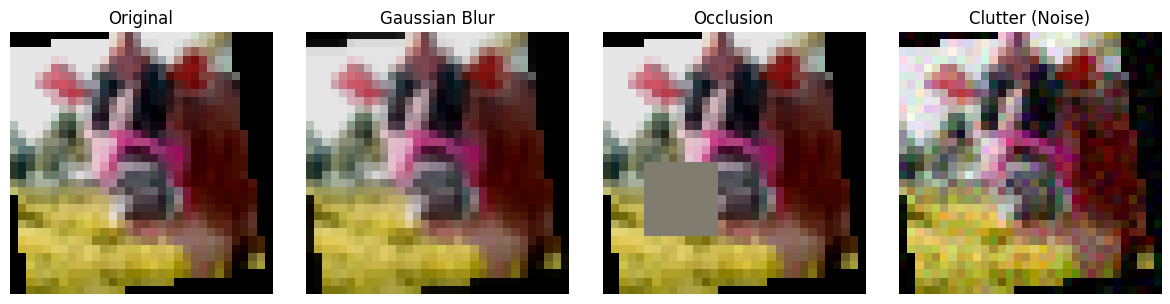

In [ ]:
# Get one image from train_dataset_final (already normalized)
image_tensor, label = train_dataset_final[0]   # shape (3,32,32), normalized
# For display, we need to unnormalize
mean = torch.tensor([0.507, 0.487, 0.441]).view(3,1,1)
std  = torch.tensor([0.267, 0.256, 0.276]).view(3,1,1)
def to_display(t):
    return (t * std + mean).clamp(0,1).permute(1,2,0).numpy()

# Define corruption functions using same parameters as add_corruption_to_tensor (heavy)
def apply_blur(img):
    blur = transforms.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0))
    return blur(img.unsqueeze(0)).squeeze(0)

def apply_occlusion(img, occlusion_ratio=0.3):
    corrupted = img.clone()
    _, h, w = corrupted.shape
    rect_h = int(h * occlusion_ratio)
    rect_w = int(w * occlusion_ratio)
    x = torch.randint(0, w - rect_w, (1,)).item()
    y = torch.randint(0, h - rect_h, (1,)).item()
    corrupted[:, y:y+rect_h, x:x+rect_w] = 0   # set to 0 (mean of normalized image)
    return corrupted

def apply_clutter(img, noise_std=0.2):
    noise = torch.randn_like(img) * noise_std
    corrupted = img + noise
    return torch.clamp(corrupted, -2, 2)

# Apply corruptions (deterministic)
# Set random seed for reproducibility of occlusion position and noise
torch.manual_seed(5201)
blurred   = apply_blur(image_tensor)
occluded  = apply_occlusion(image_tensor)
cluttered = apply_clutter(image_tensor)

# Display original and corrupted images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(to_display(image_tensor))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(to_display(blurred))
axes[1].set_title("Gaussian Blur")
axes[1].axis('off')

axes[2].imshow(to_display(occluded))
axes[2].set_title("Occlusion")
axes[2].axis('off')

axes[3].imshow(to_display(cluttered))
axes[3].set_title("Clutter (Noise)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Image encoder
Lightweight CNN encoder

In [ ]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, embedding_dim=128, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.projection = nn.Linear(512, embedding_dim)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 32→16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 16→8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 8→4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))   # 4→2
        x = self.gap(x)                                  # (batch, 512, 1, 1)
        x = x.view(x.size(0), -1)                        # (batch, 512)
        x = self.dropout(x)
        x = self.projection(x)                           # (batch, embedding_dim)
        return x

# --- Ensure device is defined ---
try:
    device
except NameError:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device not found, using: {device}")

# --- Use embedding_dim from config ---
try:
    embedding_dim = config.embedding_dim
    print(f"Using embedding_dim from config: {embedding_dim}")
except NameError:
    embedding_dim = 128
    print("Config not found, using default embedding_dim=128")

# Test the encoder
test_encoder = SimpleCNNEncoder(embedding_dim=embedding_dim, dropout=0.5).to(device)
dummy_images = torch.randn(5, 3, 32, 32).to(device)
test_embeddings = test_encoder(dummy_images)
print(f"Encoder output shape: {test_embeddings.shape}")

Using embedding_dim from config: 128
Encoder output shape: torch.Size([5, 128])


### Baseline method
This class implements the standard Prototypical Network.

It uses a feature extractor (ConvEncoder) and computes prototypes by averaging support embeddings.

Only the feature extractor is trainable.

In [ ]:
class BaselineMethod(nn.Module):

    def __init__(self, feature_extractor):
        super(BaselineMethod, self).__init__()
        self.feature_extractor = feature_extractor  # The only trainable part

    def compute_prototypes(self, support_features, support_labels, n_way):

        prototypes = []
        for class_id in range(n_way):
            # Get features for this class
            class_features = support_features[support_labels == class_id]
            # Simple average (all examples have equal weight)
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        return torch.stack(prototypes)

    def forward(self, support_images, support_labels, query_images, n_way):

        # Step 1: Extract features from both support and query
        support_features = self.feature_extractor(support_images)
        query_features   = self.feature_extractor(query_images)

        # Step 2: Compute prototypes from support features
        prototypes = self.compute_prototypes(support_features, support_labels, n_way)

        # Step 3: Compare query features to prototypes (negative squared Euclidean distance)
        distances = torch.cdist(query_features, prototypes, p=2) ** 2
        logits = -distances   # Higher logit = closer to prototype

        return logits, prototypes

### Attention method

In [ ]:
class AttentionMethod(nn.Module):
    def __init__(self, feature_extractor, embedding_dim=64, hidden_dim=128, dropout_rate=0.2, num_classes_per_episode=5):
        super(AttentionMethod, self).__init__()
        self.feature_extractor = feature_extractor
        self.num_classes_per_episode = num_classes_per_episode

        # Quality network (allows negative scores for corrupted images)
        self.quality_network = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1) # can output negative values
        )

        # Strategy 1: Global Gate (scales down entire prototype for corrupted classes)
        self.global_gate = nn.Sequential(
            nn.Linear(embedding_dim, 1),
            nn.Sigmoid()
        )


        # Strategy 2: Uncertainty estimation
        self.uncertainty_head = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus()  # Output positive uncertainty
        )

        # Learnable temperature
        self.temperature = nn.Parameter(torch.ones(1) * 0.5)

        # Strategy 3: Prior Generator
        # Input: concatenated mean and variance (2 * embedding_dim)
        # Output: prior prototype (embedding_dim)
        self.prior_generator = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self._init_weights()

    def _init_weights(self):
        for module in self.quality_network.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)

        # Initialize global gate bias to allow some signal initially
        for module in self.global_gate.modules():
            if isinstance(module, nn.Linear):
                nn.init.constant_(module.bias, 1.0)

        # Initialize uncertainty head to output small values
        for module in self.uncertainty_head.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                nn.init.constant_(module.bias, 0.0)

        # NEW: Initialize prior_generator
        for module in self.prior_generator.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)

    def compute_prototypes(self, support_features, support_labels, n_way):
        """
        Compute prototypes using:
        1. Attention weighting (quality network)
        2. Prior generated from support statistics (mean + variance)
        3. Global gate (scale down entire class)
        4. Uncertainty estimation
        """
        prototypes = []
        attention_weights_list = []
        uncertainties = []

        for class_id in range(n_way):
            # Get features for this class
            class_features = support_features[support_labels == class_id]   # (k_shot, D)

            # Quality scores (negative = corrupted, positive = clean)
            quality_scores = self.quality_network(class_features).squeeze(-1)

            # --- Prior Generator ---
            # Compute mean and variance over support features
            mean = class_features.mean(dim=0)                     # (D,)
            var = class_features.var(dim=0, unbiased=False)       # (D,)
            stats = torch.cat([mean, var], dim=0)                 # (2*D,)
            prior = self.prior_generator(stats.unsqueeze(0)).squeeze(0)  # (D,)

            # --- Uncertainty ---
            class_uncertainty = self.uncertainty_head(mean.unsqueeze(0))
            uncertainties.append(class_uncertainty)

            # --- Attention weighting ---
            temp = torch.clamp(self.temperature, min=0.1, max=2.0)
            attn_weights = F.softmax(quality_scores / temp, dim=0)
            prototype_from_support = torch.sum(class_features * attn_weights.unsqueeze(-1), dim=0)

            # --- Confidence for blending (based on max quality) ---
            max_quality = torch.max(quality_scores)
            prior_confidence = torch.sigmoid(max_quality)   # 0..1

            # Blend prior with support prototype
            final_prototype = (1 - prior_confidence) * prior + prior_confidence * prototype_from_support

            # --- Global Gate ---
            gate_value = self.global_gate(mean.unsqueeze(0))
            final_prototype = final_prototype * gate_value.squeeze()

            # L2 normalize
            final_prototype = F.normalize(final_prototype, p=2, dim=0)

            prototypes.append(final_prototype)
            attention_weights_list.append(attn_weights.detach().cpu().numpy())

        return torch.stack(prototypes), attention_weights_list, uncertainties

    def forward(self, support_images, support_labels, query_images, n_way):
        # Extract features
        support_features = self.feature_extractor(support_images)
        query_features = self.feature_extractor(query_images)

        # L2 normalize
        support_features = F.normalize(support_features, p=2, dim=-1)
        query_features = F.normalize(query_features, p=2, dim=-1)

        # Compute prototypes (prior is generated inside)
        prototypes, attention_weights, uncertainties = self.compute_prototypes(
            support_features, support_labels, n_way
        )

        # Cosine similarity
        similarities = torch.matmul(query_features, prototypes.T)

        # Uncertainty penalty
        uncertainties_tensor = torch.cat(uncertainties, dim=0).squeeze()
        uncertainty_penalty = torch.clamp(uncertainties_tensor, max=1.0)

        logits = similarities / 0.1 - uncertainty_penalty.unsqueeze(0) * 0.5

        return logits, prototypes, attention_weights

### Training function

Regularization to prevent attention collapse


In [ ]:
def compute_attention_regularization(attention_weights_list, n_way, k_shot):

    if not attention_weights_list:
        return 0.0

    reg_loss = 0.0

    for class_weights in attention_weights_list:
        weights = torch.tensor(class_weights, device='cuda' if torch.cuda.is_available() else 'cpu')

        # 1. Entropy regularization (encourage focused but not collapsed attention)
        entropy = -torch.sum(weights * torch.log(weights + 1e-8))
        target_entropy = torch.log(torch.tensor(float(k_shot))) * 0.6  # 60% of max entropy
        entropy_loss = (entropy - target_entropy) ** 2

        # 2. Sparsity regularization (encourage focusing on few samples)
        # Lower value = more focused attention
        sparsity = 1.0 - torch.sum(weights ** 2)  # 1 - sum(p^2)
        sparsity_loss = sparsity * 0.1  # Encourage some sparsity

        # 3. Max weight regularization (prevent single sample domination)
        max_weight = torch.max(weights)
        max_loss = torch.relu(max_weight - 0.7) * 0.5  # Penalize if any weight > 0.7

        reg_loss += entropy_loss + sparsity_loss + max_loss

    return reg_loss / len(attention_weights_list)

**Few-shot training function**

This function trains a few-shot model using precomputed episodes.

It shows per-episode progress bars that update in-place (single line per epoch).


In [ ]:
def train_few_shot_model(
    model,                 # instance of BaselineMethod or AttentionMethod
    train_dataset,         # dataset for training
    val_dataset,           # dataset for validation
    train_episodes,        # list of precomputed training episodes (one per epoch)
    val_episodes,          # list of precomputed validation episodes
    device,                # 'cuda' or 'cpu'
    n_way,                 # number of classes per episode
    learning_rate=0.001,
    weight_decay=1e-2,
    num_epochs=None,       # if None, use len(train_episodes)
    save_best=True,
    save_dir='.',
    model_name='model',
    save_encoder=True,
    apply_corruption=True,
    corruption_prob=0.6,
    corruption_strength='heavy',
    corruption_seed=42,
    config_dict=None
):
    """
    Train a few-shot model and save epoch‑level metrics.
    Shows episode‑level progress bars that update in‑place (one line per epoch).
    """
    if num_epochs is None:
        num_epochs = len(train_episodes)
    else:
        num_epochs = min(num_epochs, len(train_episodes))

    corruption_rng = random.Random(corruption_seed)
    model = model.to(device)
    model.train()

    # Different optimizers for Attention vs Baseline
    if isinstance(model, AttentionMethod):
        # Separate parameter groups for different components
        optimizer = torch.optim.AdamW([
            {'params': model.feature_extractor.parameters(), 'lr': learning_rate, 'weight_decay': weight_decay},
            {'params': model.quality_network.parameters(), 'lr': learning_rate * 2, 'weight_decay': 0.01},
            {'params': model.global_gate.parameters(), 'lr': learning_rate, 'weight_decay': 0.01},
            {'params': model.uncertainty_head.parameters(), 'lr': learning_rate, 'weight_decay': 0.01},
            {'params': model.prior_generator.parameters(), 'lr': learning_rate, 'weight_decay': 0.01},
            {'params': model.temperature, 'lr': learning_rate * 0.1, 'weight_decay': 0}
        ])

        # OneCycleLR for better convergence
        total_steps = num_epochs * len(train_episodes[0])
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=[learning_rate, learning_rate*2, learning_rate, learning_rate, learning_rate, learning_rate*0.1],
            total_steps=total_steps,
            pct_start=0.3
        )
    else:
        # Baseline model uses standard optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    epoch_times = []

    best_val_acc = -1.0
    best_train_loss = float('inf')

    # Outer epoch progress bar
    epoch_bar = tqdm(range(num_epochs), desc=f"Training {model_name}", unit="epoch", position=0)

    for epoch in epoch_bar:
        start_time = time.time()

        # ---------- Training ----------
        model.train()
        epoch_train_loss = 0.0
        epoch_train_acc = 0.0
        num_train_episodes = len(train_episodes[epoch])

        # Inner episode progress bar
        episode_bar = tqdm(
            train_episodes[epoch],
            desc=f"Epoch {epoch+1}/{num_epochs} - Training",
            unit="episode",
            leave=True,
            position=1,
            ncols=500
        )

        for ep_data in episode_bar:
            # Extract indices and original labels
            support_idxs = ep_data['support_indices']
            query_idxs   = ep_data['query_indices']
            support_labels_orig = torch.tensor(ep_data['support_labels'])
            query_labels_orig   = torch.tensor(ep_data['query_labels'])

            # Map to local indices (0..n_way-1)
            unique_classes = torch.unique(support_labels_orig).sort().values
            if len(unique_classes) != n_way:
                continue
            class_to_idx = {cls.item(): idx for idx, cls in enumerate(unique_classes)}
            support_labels = torch.tensor([class_to_idx[cls.item()] for cls in support_labels_orig]).to(device)
            query_labels   = torch.tensor([class_to_idx[cls.item()] for cls in query_labels_orig]).to(device)

            # Load images
            support_imgs = torch.stack([train_dataset[i][0] for i in support_idxs]).to(device)
            query_imgs   = torch.stack([train_dataset[i][0] for i in query_idxs]).to(device)

            # Apply corruption if enabled
            if apply_corruption:
                support_imgs = add_corruption_to_tensor(support_imgs,
                                                        prob=corruption_prob,
                                                        strength=corruption_strength,
                                                        rng=corruption_rng)

            # FORWARD PASS
            if isinstance(model, AttentionMethod):
                logits, prototypes, attention_weights = model(support_imgs, support_labels, query_imgs, n_way)
                ce_loss = criterion(logits, query_labels)
                entropy_reg = compute_attention_regularization(attention_weights, n_way, config.k_shot)
                loss = ce_loss + 0.01 * entropy_reg
            else:
                logits, _ = model(support_imgs, support_labels, query_imgs, n_way)
                loss = criterion(logits, query_labels)

            # Calculate accuracy (ALWAYS do this AFTER forward pass)
            pred = torch.argmax(logits, dim=1)
            acc = (pred == query_labels).float().mean().item()

            # Update progress bar with metrics
            if isinstance(model, AttentionMethod):
                # Monitor attention statistics
                if np.random.random() < 0.01 and len(attention_weights) > 0:
                    avg_entropy = 0
                    avg_max_weight = 0
                    for w in attention_weights:
                        w_tensor = torch.tensor(w)
                        entropy = -torch.sum(w_tensor * torch.log(w_tensor + 1e-8)).item()
                        avg_entropy += entropy
                        avg_max_weight += np.max(w)
                    avg_entropy /= len(attention_weights)
                    avg_max_weight /= len(attention_weights)
                    episode_bar.set_postfix(
                        loss=loss.item(),
                        acc=acc,
                        ent=f"{avg_entropy:.2f}",
                        max_w=f"{avg_max_weight:.2f}"
                    )
                else:
                    episode_bar.set_postfix(loss=loss.item(), acc=acc)
            else:
                episode_bar.set_postfix(loss=loss.item(), acc=acc)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping for attention model stability
            if isinstance(model, AttentionMethod):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Accumulate metrics
            epoch_train_loss += loss.item()
            epoch_train_acc += acc

        # Close inner bar
        episode_bar.close()

        avg_train_loss = epoch_train_loss / num_train_episodes
        avg_train_acc = epoch_train_acc / num_train_episodes
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)

        # ---------- Validation ----------
        if val_episodes is not None and len(val_episodes) > 0:
            model.eval()
            val_loss = 0.0
            val_acc = 0.0
            num_val_episodes = len(val_episodes)

            val_bar = tqdm(
                val_episodes,
                desc=f"Epoch {epoch+1}/{num_epochs} - Validating",
                unit="episode",
                leave=False,
                position=1,
                ncols=500
            )

            with torch.no_grad():
                for ep_data in val_bar:
                    support_idxs = ep_data['support_indices']
                    query_idxs   = ep_data['query_indices']
                    support_labels_orig = torch.tensor(ep_data['support_labels'])
                    query_labels_orig   = torch.tensor(ep_data['query_labels'])

                    unique_classes = torch.unique(support_labels_orig).sort().values
                    actual_n_way = len(unique_classes)
                    class_to_idx = {cls.item(): idx for idx, cls in enumerate(unique_classes)}

                    support_labels = torch.tensor([class_to_idx[cls.item()] for cls in support_labels_orig]).to(device)
                    query_labels   = torch.tensor([class_to_idx[cls.item()] for cls in query_labels_orig]).to(device)

                    support_imgs = torch.stack([val_dataset[i][0] for i in support_idxs]).to(device)
                    query_imgs   = torch.stack([val_dataset[i][0] for i in query_idxs]).to(device)

                    if isinstance(model, AttentionMethod):
                        logits, _, _ = model(support_imgs, support_labels, query_imgs, actual_n_way)
                    else:
                        logits, _ = model(support_imgs, support_labels, query_imgs, actual_n_way)

                    loss = criterion(logits, query_labels)
                    pred = torch.argmax(logits, dim=1)
                    acc = (pred == query_labels).float().mean().item()

                    val_loss += loss.item()
                    val_acc += acc

                    val_bar.set_postfix(loss=loss.item(), acc=acc)

            avg_val_loss = val_loss / num_val_episodes
            avg_val_acc = val_acc / num_val_episodes
            val_losses.append(avg_val_loss)
            val_accs.append(avg_val_acc)

            val_bar.close()

            # Update outer bar
            epoch_bar.set_postfix(
                train_loss=avg_train_loss, train_acc=avg_train_acc,
                val_loss=avg_val_loss, val_acc=avg_val_acc
            )

            # Save best model
            if save_best and avg_val_acc > best_val_acc:
                best_val_acc = avg_val_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_acc': best_val_acc,
                    'val_loss': avg_val_loss,
                    'train_acc': avg_train_acc,
                    'train_loss': avg_train_loss
                }, os.path.join(save_dir, f'{model_name}_best_full.pth'))
                if save_encoder and hasattr(model, 'feature_extractor'):
                    torch.save(model.feature_extractor.state_dict(),
                               os.path.join(save_dir, f'{model_name}_best_encoder.pth'))
                tqdm.write(f"\nBest model saved (val_acc={best_val_acc:.4f}) on {epoch+1} epoch")

        else:
            epoch_bar.set_postfix(train_loss=avg_train_loss, train_acc=avg_train_acc)
            if save_best and avg_train_loss < best_train_loss:
                best_train_loss = avg_train_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'train_loss': best_train_loss,
                    'train_acc': avg_train_acc
                }, os.path.join(save_dir, f'{model_name}_best_full.pth'))
                if save_encoder and hasattr(model, 'feature_extractor'):
                    torch.save(model.feature_extractor.state_dict(),
                               os.path.join(save_dir, f'{model_name}_best_encoder.pth'))
                tqdm.write(f"Best model saved (train_loss={best_train_loss:.4f})")

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        # Step the scheduler
        if isinstance(model, AttentionMethod):
            scheduler.step()
        else:
            scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']

        # Print epoch summary
        if val_episodes is not None and len(val_episodes) > 0:
            tqdm.write(
                f"\n=== Epoch {epoch+1}/{num_epochs} ===\n"
                f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.2%}\n"
                f"Val Loss  : {avg_val_loss:.4f}, Val Acc  : {avg_val_acc:.2%}\n"
                f"⏱️ Epoch time: {epoch_time:.2f}s, LR: {current_lr:.6f}\n"
            )
        else:
            tqdm.write(
                f"\n=== Epoch {epoch+1}/{num_epochs} ===\n"
                f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.2%}\n"
                f"⏱️ Epoch time: {epoch_time:.2f}s, LR: {current_lr:.6f}\n"
            )

    # Save metrics
    metrics = {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'epoch_times': epoch_times,
        'avg_epoch_time': sum(epoch_times) / len(epoch_times) if epoch_times else 0,
    }

    if config_dict is not None:
        config_attrs = {
                key: value
                for key, value in config_dict.__class__.__dict__.items()
                if not key.startswith('__') and not callable(value)
              }
        metrics['config'] = config_attrs

    with open(os.path.join(save_dir, f'{model_name}_metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=2)

    tqdm.write(f"Training finished. Metrics saved to {save_dir}/{model_name}_metrics.json")
    return model

### Create training episodes
Generate a fixed set of training episodes (one per epoch) using the training classes.

Each episode contains n_way classes, each with k_shot support and k_query query examples.

The episodes are precomputed to ensure deterministic training.

In [ ]:
print("Precomputing training episodes...")

# Use training classes and dataset
episodes = precompute_episodes(
    dataset=train_dataset_final,
    class_list=train_classes,
    num_epochs=50,                      # number of training epochs (adjust as needed)
    episodes_per_epoch=500,             # episodes per epoch (you can adjust)
    n_way=config.n_way,                 # 5-way
    k_shot=config.k_shot,               # 5-shot
    k_query=config.k_query,             # 10 query (matches config)
    seed=config.seed
)

print(f"Precomputed {len(episodes)} epochs, each with {len(episodes[0])} episodes.")

Precomputing training episodes...
Building class-to-index mapping...


Indexing dataset:   0%|          | 0/38400 [00:00<?, ?it/s]

Epoch 1/50 precomputed.
Epoch 2/50 precomputed.
Epoch 3/50 precomputed.
Epoch 4/50 precomputed.
Epoch 5/50 precomputed.
Epoch 6/50 precomputed.
Epoch 7/50 precomputed.
Epoch 8/50 precomputed.
Epoch 9/50 precomputed.
Epoch 10/50 precomputed.
Epoch 11/50 precomputed.
Epoch 12/50 precomputed.
Epoch 13/50 precomputed.
Epoch 14/50 precomputed.
Epoch 15/50 precomputed.
Epoch 16/50 precomputed.
Epoch 17/50 precomputed.
Epoch 18/50 precomputed.
Epoch 19/50 precomputed.
Epoch 20/50 precomputed.
Epoch 21/50 precomputed.
Epoch 22/50 precomputed.
Epoch 23/50 precomputed.
Epoch 24/50 precomputed.
Epoch 25/50 precomputed.
Epoch 26/50 precomputed.
Epoch 27/50 precomputed.
Epoch 28/50 precomputed.
Epoch 29/50 precomputed.
Epoch 30/50 precomputed.
Epoch 31/50 precomputed.
Epoch 32/50 precomputed.
Epoch 33/50 precomputed.
Epoch 34/50 precomputed.
Epoch 35/50 precomputed.
Epoch 36/50 precomputed.
Epoch 37/50 precomputed.
Epoch 38/50 precomputed.
Epoch 39/50 precomputed.
Epoch 40/50 precomputed.
Epoch 41/

### Create fixed validation episodes

In [ ]:
print("Creating fixed validation episodes (5-way) for stable evaluation...")

# Build mapping from class to list of indices in val_dataset_final
class_to_indices_val = {}
for idx, (_, label) in enumerate(val_dataset_final):
    if label not in class_to_indices_val:
        class_to_indices_val[label] = []
    class_to_indices_val[label].append(idx)

# Use all validation classes (16 classes)
available_val_classes = val_classes.copy()
print(f"Available validation classes: {len(available_val_classes)} classes")

# Configuration for validation episodes
NUM_VAL_EPISODES = 200           # 200 for stable validation
N_WAY_VAL = 5                    # 5-way
K_SHOT_VAL = 5                   # support images per class
K_QUERY_VAL = 15                 # query images per class

# Fixed random seed for reproducibility
random.seed(42)

val_episodes_list = []

for episode_idx in range(NUM_VAL_EPISODES):
    # Randomly choose 5 classes from the 16 validation classes (with replacement allowed)
    episode_classes = random.sample(available_val_classes, N_WAY_VAL)

    support_indices = []
    support_labels = []
    query_indices = []
    query_labels = []

    for cls in episode_classes:
        # Get all indices for this class
        indices = class_to_indices_val[cls].copy()

        # Use fixed indices (first 20 images) for all epochs
        fixed_indices = indices[:20]   # first 20 images

        # Support: first 5 images
        support_indices.extend(fixed_indices[:K_SHOT_VAL])
        support_labels.extend([cls] * K_SHOT_VAL)

        # Query: next 15 images
        query_indices.extend(fixed_indices[K_SHOT_VAL:K_SHOT_VAL + K_QUERY_VAL])
        query_labels.extend([cls] * K_QUERY_VAL)

    val_episode = {
        'support_indices': support_indices,
        'support_labels': support_labels,
        'query_indices': query_indices,
        'query_labels': query_labels,
        'classes': episode_classes   # store for reference
    }
    val_episodes_list.append(val_episode)

print(f"\n{'='*70}")
print(f"✅ Created {len(val_episodes_list)} fixed validation episodes")
print(f"{'='*70}")
print(f"Configuration:")
print(f"  • {NUM_VAL_EPISODES} episodes per epoch")
print(f"  • {N_WAY_VAL} classes per episode")
print(f"  • {K_SHOT_VAL} support images per class → {N_WAY_VAL * K_SHOT_VAL} total support images per episode")
print(f"  • {K_QUERY_VAL} query images per class → {N_WAY_VAL * K_QUERY_VAL} total query images per episode")
print(f"\nImages are FIXED (same support and query images for all epochs)")

Creating fixed validation episodes (5-way) for stable evaluation...
Available validation classes: 16 classes

✅ Created 200 fixed validation episodes
Configuration:
  • 200 episodes per epoch
  • 5 classes per episode
  • 5 support images per class → 25 total support images per episode
  • 15 query images per class → 75 total query images per episode

Images are FIXED (same support and query images for all epochs)


### Train baseline
Train the baseline model (simple averaging) using a fresh encoder.

The encoder is created separately to ensure fairness with the attention model.

In [ ]:
# Create a fresh encoder for baseline
baseline_encoder = SimpleCNNEncoder(embedding_dim=config.embedding_dim, dropout=0.5).to(device)
baseline_model = BaselineMethod(baseline_encoder).to(device)

# Train baseline
baseline_model = train_few_shot_model(
    model=baseline_model,
    train_dataset=train_dataset_final,
    val_dataset=val_dataset_final,
    train_episodes=episodes,
    val_episodes=val_episodes_list,
    device=device,
    n_way=config.n_way,
    learning_rate=config.learning_rate,
    weight_decay=5e-3,
    num_epochs=len(episodes),              # 50 epochs
    save_dir=config.save_dir,
    model_name='baseline',
    save_encoder=True,
    apply_corruption=config.use_blurry_training,
    corruption_prob=config.blur_probability,
    corruption_strength=config.blur_strength,
    config_dict = config
)

Training baseline:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 - Training:   0%|                                                                                  …

Epoch 1/50 - Validating:   0%|                                                                                …


Best model saved (val_acc=0.3913) on 1 epoch

=== Epoch 1/50 ===
Train Loss: 2.0062, Train Acc: 28.51%
Val Loss  : 1.4315, Val Acc  : 39.13%
⏱️ Epoch time: 65.21s, LR: 0.000999



Epoch 2/50 - Training:   0%|                                                                                  …

...

Epoch 49/50 - Validating:   0%|                                                                               …


=== Epoch 49/50 ===
Train Loss: 1.0138, Train Acc: 67.90%
Val Loss  : 1.1823, Val Acc  : 59.53%
⏱️ Epoch time: 67.55s, LR: 0.000002



Epoch 50/50 - Training:   0%|                                                                                 …

Epoch 50/50 - Validating:   0%|                                                                               …


=== Epoch 50/50 ===
Train Loss: 1.0081, Train Acc: 68.52%
Val Loss  : 1.1875, Val Acc  : 59.73%
⏱️ Epoch time: 71.19s, LR: 0.000001

Training finished. Metrics saved to ./saved_models/baseline_metrics.json


### Train attention
Train the attention model using a fresh encoder (same initial weights as baseline).

The corruption settings are kept identical to baseline for fair comparison.

In [ ]:
# Create a fresh encoder for attention (same initial weights)
attention_encoder = SimpleCNNEncoder(embedding_dim=config.embedding_dim, dropout=0.5).to(device)
attention_model = AttentionMethod(attention_encoder, embedding_dim=config.embedding_dim, hidden_dim=config.hidden_dim).to(device)

# Train attention model
attention_model = train_few_shot_model(
    model=attention_model,
    train_dataset=train_dataset_final,
    val_dataset=val_dataset_final,
    train_episodes=episodes,
    val_episodes=val_episodes_list,
    device=device,
    n_way=config.n_way,
    learning_rate=config.learning_rate,
    weight_decay=5e-3,
    num_epochs=len(episodes),
    save_dir=config.save_dir,
    model_name='attention',
    save_encoder=True,
    apply_corruption=config.use_blurry_training,
    corruption_prob=config.blur_probability,
    corruption_strength=config.blur_strength,
    config_dict = config
)

Training attention:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 - Training:   0%|                                                                                  …

Epoch 1/50 - Validating:   0%|                                                                                …


Best model saved (val_acc=0.5046) on 1 epoch

=== Epoch 1/50 ===
Train Loss: 1.4785, Train Acc: 37.27%
Val Loss  : 1.2709, Val Acc  : 50.46%
⏱️ Epoch time: 80.63s, LR: 0.000040



Epoch 2/50 - Training:   0%|                                                                                  …

...

Epoch 49/50 - Validating:   0%|                                                                               …


=== Epoch 49/50 ===
Train Loss: 0.9428, Train Acc: 71.91%
Val Loss  : 1.1156, Val Acc  : 64.32%
⏱️ Epoch time: 80.94s, LR: 0.000040



Epoch 50/50 - Training:   0%|                                                                                 …

Epoch 50/50 - Validating:   0%|                                                                               …


=== Epoch 50/50 ===
Train Loss: 0.9323, Train Acc: 72.68%
Val Loss  : 1.1083, Val Acc  : 63.57%
⏱️ Epoch time: 81.48s, LR: 0.000040

Training finished. Metrics saved to ./saved_models/attention_metrics.json


### Visualization
Plot training / validation curves and test evaluation

In [ ]:
# Load metrics for plotting
def load_metrics(model_name, save_dir='./saved_models'):
    with open(os.path.join(save_dir, f'{model_name}_metrics.json'), 'r') as f:
        metrics = json.load(f)
    return metrics


def plot_curves(metrics_baseline, metrics_attention, save_dir='./results'):
    epochs = np.arange(1, len(metrics_baseline['train_accs']) + 1)

    # Find best validation accuracy and its epoch
    best_baseline_acc = max(metrics_baseline['val_accs'])
    best_baseline_epoch = np.argmax(metrics_baseline['val_accs']) + 1
    best_attention_acc = max(metrics_attention['val_accs'])
    best_attention_epoch = np.argmax(metrics_attention['val_accs']) + 1

    # Best validation loss (lowest)
    best_baseline_loss = min(metrics_baseline['val_losses'])
    best_baseline_loss_epoch = np.argmin(metrics_baseline['val_losses']) + 1
    best_attention_loss = min(metrics_attention['val_losses'])
    best_attention_loss_epoch = np.argmin(metrics_attention['val_losses']) + 1

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ----- Accuracy subplot -----
    ax = axes[0]
    # Plot curves
    ax.plot(epochs, metrics_baseline['train_accs'], 'b-', label='Baseline Train', linewidth=2)
    ax.plot(epochs, metrics_baseline['val_accs'], 'b--', label='Baseline Val', linewidth=2)
    ax.plot(epochs, metrics_attention['train_accs'], 'r-', label='Attention Train', linewidth=2)
    ax.plot(epochs, metrics_attention['val_accs'], 'r--', label='Attention Val', linewidth=2)

    # Horizontal dotted line + circle for baseline best validation accuracy
    ax.axhline(y=best_baseline_acc, color='b', linestyle=':', alpha=0.7, linewidth=1.5)
    ax.plot(best_baseline_epoch, best_baseline_acc, 'bo', markersize=8, markeredgecolor='black', markeredgewidth=1)
    # ax.text(best_baseline_epoch + 0.5, best_baseline_acc, f'{best_baseline_acc:.3f}', fontsize=9, color='b')

    # Horizontal dotted line + circle for attention best validation accuracy
    ax.axhline(y=best_attention_acc, color='r', linestyle=':', alpha=0.7, linewidth=1.5)
    ax.plot(best_attention_epoch, best_attention_acc, 'ro', markersize=8, markeredgecolor='black', markeredgewidth=1)
    # ax.text(best_attention_epoch + 0.5, best_attention_acc, f'{best_attention_acc:.3f}', fontsize=9, color='r')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Training and Validation Accuracy')
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.5)

    # ----- Loss subplot -----
    ax = axes[1]
    ax.plot(epochs, metrics_baseline['train_losses'], 'b-', label='Baseline Train', linewidth=2)
    ax.plot(epochs, metrics_baseline['val_losses'], 'b--', label='Baseline Val', linewidth=2)
    ax.plot(epochs, metrics_attention['train_losses'], 'r-', label='Attention Train', linewidth=2)
    ax.plot(epochs, metrics_attention['val_losses'], 'r--', label='Attention Val', linewidth=2)

    # Horizontal dotted line + circle for best validation loss (lowest)
    ax.axhline(y=best_baseline_loss, color='b', linestyle=':', alpha=0.7, linewidth=1.5)
    ax.plot(best_baseline_loss_epoch, best_baseline_loss, 'bo', markersize=8, markeredgecolor='black', markeredgewidth=1)
    # ax.text(best_baseline_loss_epoch + 0.5, best_baseline_loss, f'{best_baseline_loss:.3f}', fontsize=9, color='b')

    ax.axhline(y=best_attention_loss, color='r', linestyle=':', alpha=0.7, linewidth=1.5)
    ax.plot(best_attention_loss_epoch, best_attention_loss, 'ro', markersize=8, markeredgecolor='black', markeredgewidth=1)
    # ax.text(best_attention_loss_epoch + 0.5, best_attention_loss, f'{best_attention_loss:.3f}', fontsize=9, color='r')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training and Validation Loss')
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    # plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=150)
    plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Baseline  - Best Val Acc: {best_baseline_acc:.4f} at epoch {best_baseline_epoch}")
    print(f"Attention - Best Val Acc: {best_attention_acc:.4f} at epoch {best_attention_epoch}")
    print(f"Baseline  - Best Val Loss: {best_baseline_loss:.4f} at epoch {best_baseline_loss_epoch}")
    print(f"Attention - Best Val Loss: {best_attention_loss:.4f} at epoch {best_attention_loss_epoch}")

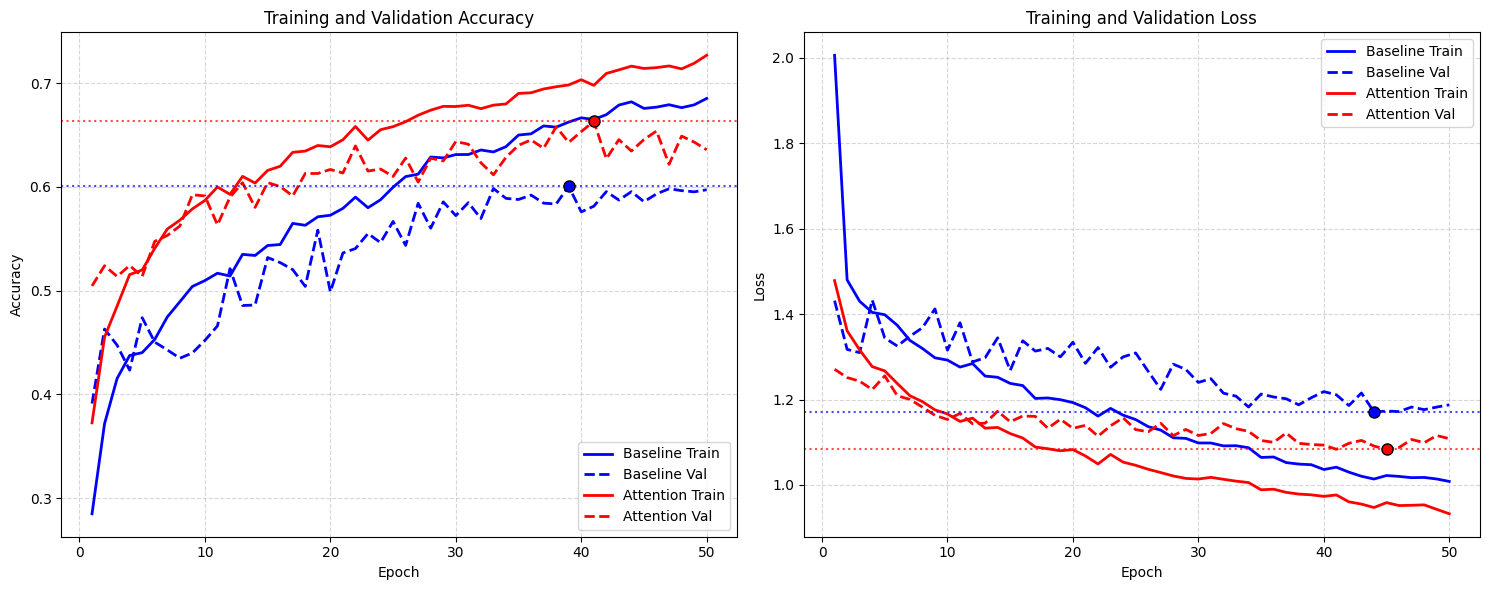

Baseline  - Best Val Acc: 0.6007 at epoch 39
Attention - Best Val Acc: 0.6632 at epoch 41
Baseline  - Best Val Loss: 1.1708 at epoch 44
Attention - Best Val Loss: 1.0833 at epoch 45


In [ ]:
# Load metrics and plot training curves
baseline_metrics = load_metrics('baseline', save_dir=config.save_dir)
attention_metrics = load_metrics('attention', save_dir=config.save_dir)

plot_curves(baseline_metrics, attention_metrics, save_dir=config.results_dir)

### Testing

Testing Configuration

In [ ]:
n_way = config.n_way          # 5
k_shot = config.k_shot        # 5
k_query = config.k_query      # 15
num_test_episodes = 500       # number of episodes for evaluation
corruption_probs = [0.0, 0.2, 0.4, 0.6]
corruption_strength = 'heavy' # same as used in training
seed = 5201

Load the saved models

In [ ]:
# Load Baseline Full Model
baseline_full_path = os.path.join(config.save_dir, 'baseline_best_full.pth')
checkpoint_b = torch.load(baseline_full_path, map_location=device)

# Create a fresh baseline model (random encoder initially)
baseline_encoder = SimpleCNNEncoder(embedding_dim=config.embedding_dim, dropout=0.5).to(device)
baseline_model = BaselineMethod(baseline_encoder).to(device)

# Load the full state dict (overwrites encoder and any other parameters)
baseline_model.load_state_dict(checkpoint_b['model_state_dict'])
baseline_model.eval()
print("Baseline encoder weight sample:", baseline_model.feature_extractor.conv1.weight[0,0,0,0].item())
print("Baseline full model loaded.\n")

# Load Attention Full Model
attention_full_path = os.path.join(config.save_dir, 'attention_best_full.pth')
checkpoint_a = torch.load(attention_full_path, map_location=device)

# Create a fresh attention model (random encoder, random quality net, etc.)
attention_encoder = SimpleCNNEncoder(embedding_dim=config.embedding_dim, dropout=0.5).to(device)
attention_model = AttentionMethod(attention_encoder,
                                  embedding_dim=config.embedding_dim,
                                  hidden_dim=config.hidden_dim).to(device)

# Load the full state dict
attention_model.load_state_dict(checkpoint_a['model_state_dict'])
attention_model.eval()
print("Attention encoder weight sample:", attention_model.feature_extractor.conv1.weight[0,0,0,0].item())
print("Attention full model loaded.")

Baseline encoder weight sample: -3.0153682217815e-08
Baseline full model loaded.

Attention encoder weight sample: 0.010557853616774082
Attention full model loaded.


Create fixed test episodes (using test classes only)

In [ ]:
random.seed(seed)
np.random.seed(seed)

# Build class -> index mapping for test_dataset_final
class_to_indices = {}
for idx, (_, label) in enumerate(test_dataset_final):
    if label in test_classes:   # test_classes is a list of class IDs (80-99)
        class_to_indices.setdefault(label, []).append(idx)

# Verify each test class has enough images
min_required = k_shot + k_query
for cls in test_classes:
    if len(class_to_indices[cls]) < min_required:
        print(f"Warning: class {cls} has only {len(class_to_indices[cls])} images, need {min_required}")

test_episodes = []
for _ in range(num_test_episodes):
    selected_classes = random.sample(test_classes, n_way)
    support_indices = []
    support_labels = []
    query_indices = []
    query_labels = []

    for cls in selected_classes:
        indices = class_to_indices[cls][:]   # copy
        random.shuffle(indices)
        support_indices.extend(indices[:k_shot])
        support_labels.extend([cls] * k_shot)
        query_indices.extend(indices[k_shot:k_shot + k_query])
        query_labels.extend([cls] * k_query)

    test_episodes.append({
        'support_indices': support_indices,
        'support_labels': support_labels,
        'query_indices': query_indices,
        'query_labels': query_labels,
        'classes': selected_classes
    })

print(f"Created {len(test_episodes)} test episodes (fixed across corruption levels).")

Created 500 test episodes (fixed across corruption levels).


Perform testing

In [ ]:
def evaluate_on_episodes(model, episodes, corruption_prob, is_attention=False):
    model.eval()
    all_preds = []
    all_labels = []
    corruption_rng = random.Random(seed)  # fixed seed for reproducibility

    with torch.no_grad():
        for ep in tqdm(episodes, desc=f"Corruption={corruption_prob}"):
            support_idxs = ep['support_indices']
            query_idxs = ep['query_indices']
            support_labels_orig = torch.tensor(ep['support_labels'])
            query_labels_orig = torch.tensor(ep['query_labels'])

            # Map to local class indices 0..n_way-1
            unique_classes = torch.unique(support_labels_orig).sort().values
            class_to_idx = {cls.item(): idx for idx, cls in enumerate(unique_classes)}
            support_labels = torch.tensor([class_to_idx[cls.item()] for cls in support_labels_orig]).to(device)
            query_labels = torch.tensor([class_to_idx[cls.item()] for cls in query_labels_orig]).to(device)

            # Load images
            support_imgs = torch.stack([test_dataset_final[i][0] for i in support_idxs]).to(device)
            query_imgs = torch.stack([test_dataset_final[i][0] for i in query_idxs]).to(device)

            # Apply corruption to support images only
            if corruption_prob > 0:
                support_imgs = add_corruption_to_tensor(support_imgs,
                                                        prob=corruption_prob,
                                                        strength=corruption_strength,
                                                        rng=corruption_rng)

            # Forward pass
            if is_attention:
                logits, _, _ = model(support_imgs, support_labels, query_imgs, n_way)
            else:
                logits, _ = model(support_imgs, support_labels, query_imgs, n_way)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labels = query_labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1

In [ ]:
# Run evaluation for each corruption probability
results = {
    'baseline': {'acc': [], 'f1': []},
    'attention': {'acc': [], 'f1': []}
}

for prob in corruption_probs:
    print(f"\n{'='*50}")
    print(f"Corruption probability = {prob}")
    print('='*50)

    acc_b, f1_b = evaluate_on_episodes(baseline_model, test_episodes, prob, is_attention=False)
    acc_a, f1_a = evaluate_on_episodes(attention_model, test_episodes, prob, is_attention=True)

    results['baseline']['acc'].append(acc_b)
    results['baseline']['f1'].append(f1_b)
    results['attention']['acc'].append(acc_a)
    results['attention']['f1'].append(f1_a)

    print(f"Baseline  -> Acc: {acc_b:.4f},  F1: {f1_b:.4f}")
    print(f"Attention -> Acc: {acc_a:.4f},  F1: {f1_a:.4f}")


Corruption probability = 0.0


Corruption=0.0: 100%|██████████| 500/500 [00:15<00:00, 32.32it/s]


Baseline  -> Acc: 0.6634,  F1: 0.6634
Attention -> Acc: 0.6966,  F1: 0.6964

Corruption probability = 0.2


Corruption=0.2: 100%|██████████| 500/500 [00:16<00:00, 30.39it/s]


Baseline  -> Acc: 0.6575,  F1: 0.6573
Attention -> Acc: 0.6953,  F1: 0.6952

Corruption probability = 0.4


Corruption=0.4: 100%|██████████| 500/500 [00:16<00:00, 30.68it/s]


Baseline  -> Acc: 0.6523,  F1: 0.6521
Attention -> Acc: 0.6902,  F1: 0.6900

Corruption probability = 0.6


Corruption=0.6: 100%|██████████| 500/500 [00:18<00:00, 27.73it/s]


Baseline  -> Acc: 0.6475,  F1: 0.6474
Attention -> Acc: 0.6838,  F1: 0.6837


Plot the testing results

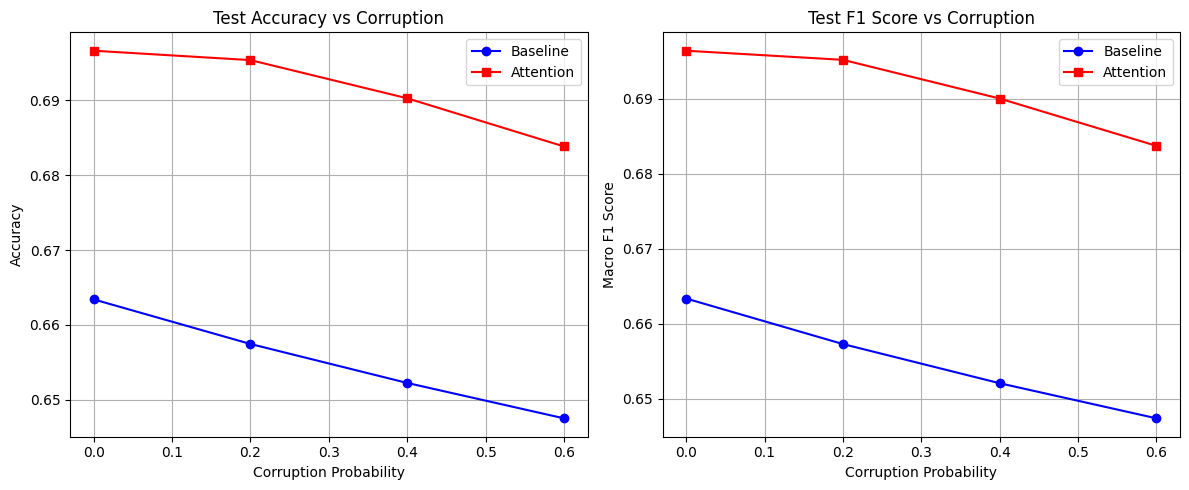


Evaluation finished. Results saved to: ./results/test_corruption_robustness.png


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(corruption_probs, results['baseline']['acc'], 'b-o', label='Baseline')
plt.plot(corruption_probs, results['attention']['acc'], 'r-s', label='Attention')
plt.xlabel('Corruption Probability')
plt.ylabel('Accuracy')
plt.title('Test Accuracy vs Corruption')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(corruption_probs, results['baseline']['f1'], 'b-o', label='Baseline')
plt.plot(corruption_probs, results['attention']['f1'], 'r-s', label='Attention')
plt.xlabel('Corruption Probability')
plt.ylabel('Macro F1 Score')
plt.title('Test F1 Score vs Corruption')
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(config.results_dir, 'test_corruption_robustness.png'), dpi=150)
plt.savefig(os.path.join(config.results_dir, 'test_corruption_robustness.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nEvaluation finished. Results saved to:", os.path.join(config.results_dir, 'test_corruption_robustness.png'))